In [113]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
# from loglike_pure_noise import LogLike
# from loglike_phasemax_noise import LogLike
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 8/12
N_SEGS = 12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}, N_segs={N_SEGS}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 7.7 #NOTE
e0 = 0.4
xI0 = 1.0
dist =  6 #NOTE: 
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                         
             

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

# data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
# print(f'SNR (time-max): {data_snr:.4f}')

print("Setting up log_density and prior functions...")



def log_density(params):
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i = params[i]
        try:
            h_temp = gwf.xp.array(waveform_response(
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                T=T, dt=dt,
            ))
            out[i] = float(gwf.SNR_semicoherent(loglike_obj.signal, h_temp, N_seg=N_SEGS))
        except Exception:
            pass
    return out



def prior_transform(u):
    logm1lim = [5.5, 6.3]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [7.0, 10.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.5, 6.3]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [7.0, 10.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u

Using dt=5s, T=0.6666666666666666yr, TDI gen=1, N_segs=12
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
Setting up log_density and prior functions...


In [114]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/stage1/anneal_s12_snr30'


In [115]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [116]:
sampler.config

SamplerConfig(seed=953453411, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=True, integral_num=100000, gamma=500, exclude_scale_z=inf, use_pool=False, n_pool=10, stop_on_merge=False, merge_type='single', cov_jitter=1e-10, keep_dead_processes=True, debug=False)

In [117]:
sampler.init_cov_list

[array([[ 0.0138247 ,  0.01157424, -0.00577923, -0.01353272,  0.00097491],
        [ 0.01157424,  0.06153471, -0.00157999,  0.00185934,  0.00158367],
        [-0.00577923, -0.00157999,  0.0630656 , -0.01173849, -0.00172414],
        [-0.01353272,  0.00185934, -0.01173849,  0.07046249,  0.00618162],
        [ 0.00097491,  0.00158367, -0.00172414,  0.00618162,  0.0586982 ]])]

In [118]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [119]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.65479051,  0.65185494,  0.83064949,  0.22752642,  0.47959363],
        [ 0.791833  ,  0.80493016,  0.73282135, -0.27474762,  0.90074521],
        [ 0.65249259,  0.18503565,  0.99237884, -0.12071047,  0.25213233],
        ...,
        [ 0.6544808 ,  0.65195081,  0.83043316,  0.22838637,  0.47949045],
        [ 0.65411614,  0.65154541,  0.82985491,  0.2291666 ,  0.48060486],
        [ 0.65522774,  0.65199351,  0.83093509,  0.22640783,  0.47825969]])]

In [120]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([493.08537204,         -inf,         -inf, ..., 481.44998295,
        480.80528602, 481.08341128])]

In [121]:
sampler.now_covariances

[array([[ 8.74811714e-08, -6.62682951e-09,  6.41040785e-08,
         -2.43321038e-07, -1.17002707e-07],
        [-6.62682951e-09,  1.99526947e-07,  1.88541639e-07,
          9.96534399e-08, -1.15732783e-07],
        [ 6.41040785e-08,  1.88541639e-07,  2.97276212e-07,
         -1.24437495e-07, -2.03488089e-07],
        [-2.43321038e-07,  9.96534399e-08, -1.24437495e-07,
          7.22488811e-07,  2.77090386e-07],
        [-1.17002707e-07, -1.15732783e-07, -2.03488089e-07,
          2.77090386e-07,  3.66410692e-07]])]

In [122]:
np.argmax(logden_list)

75551

In [123]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.02349103, 1.12567941, 0.8728248 , 7.68499057, 0.34427594]])

In [124]:
log_density(maxld_pt1)

array([16.76062199])

In [125]:
log_density([param_true])

array([25.03443669])

In [126]:
param_ranges = [(5.5,6.3),
                (0.8,1.3),
                (0.3,0.99),
                (7.0,10.0),
                (0.2,0.5),
                ]
param_ranges

[(5.5, 6.3), (0.8, 1.3), (0.3, 0.99), (7.0, 10.0), (0.2, 0.5)]

In [127]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 7.7, 0.4]

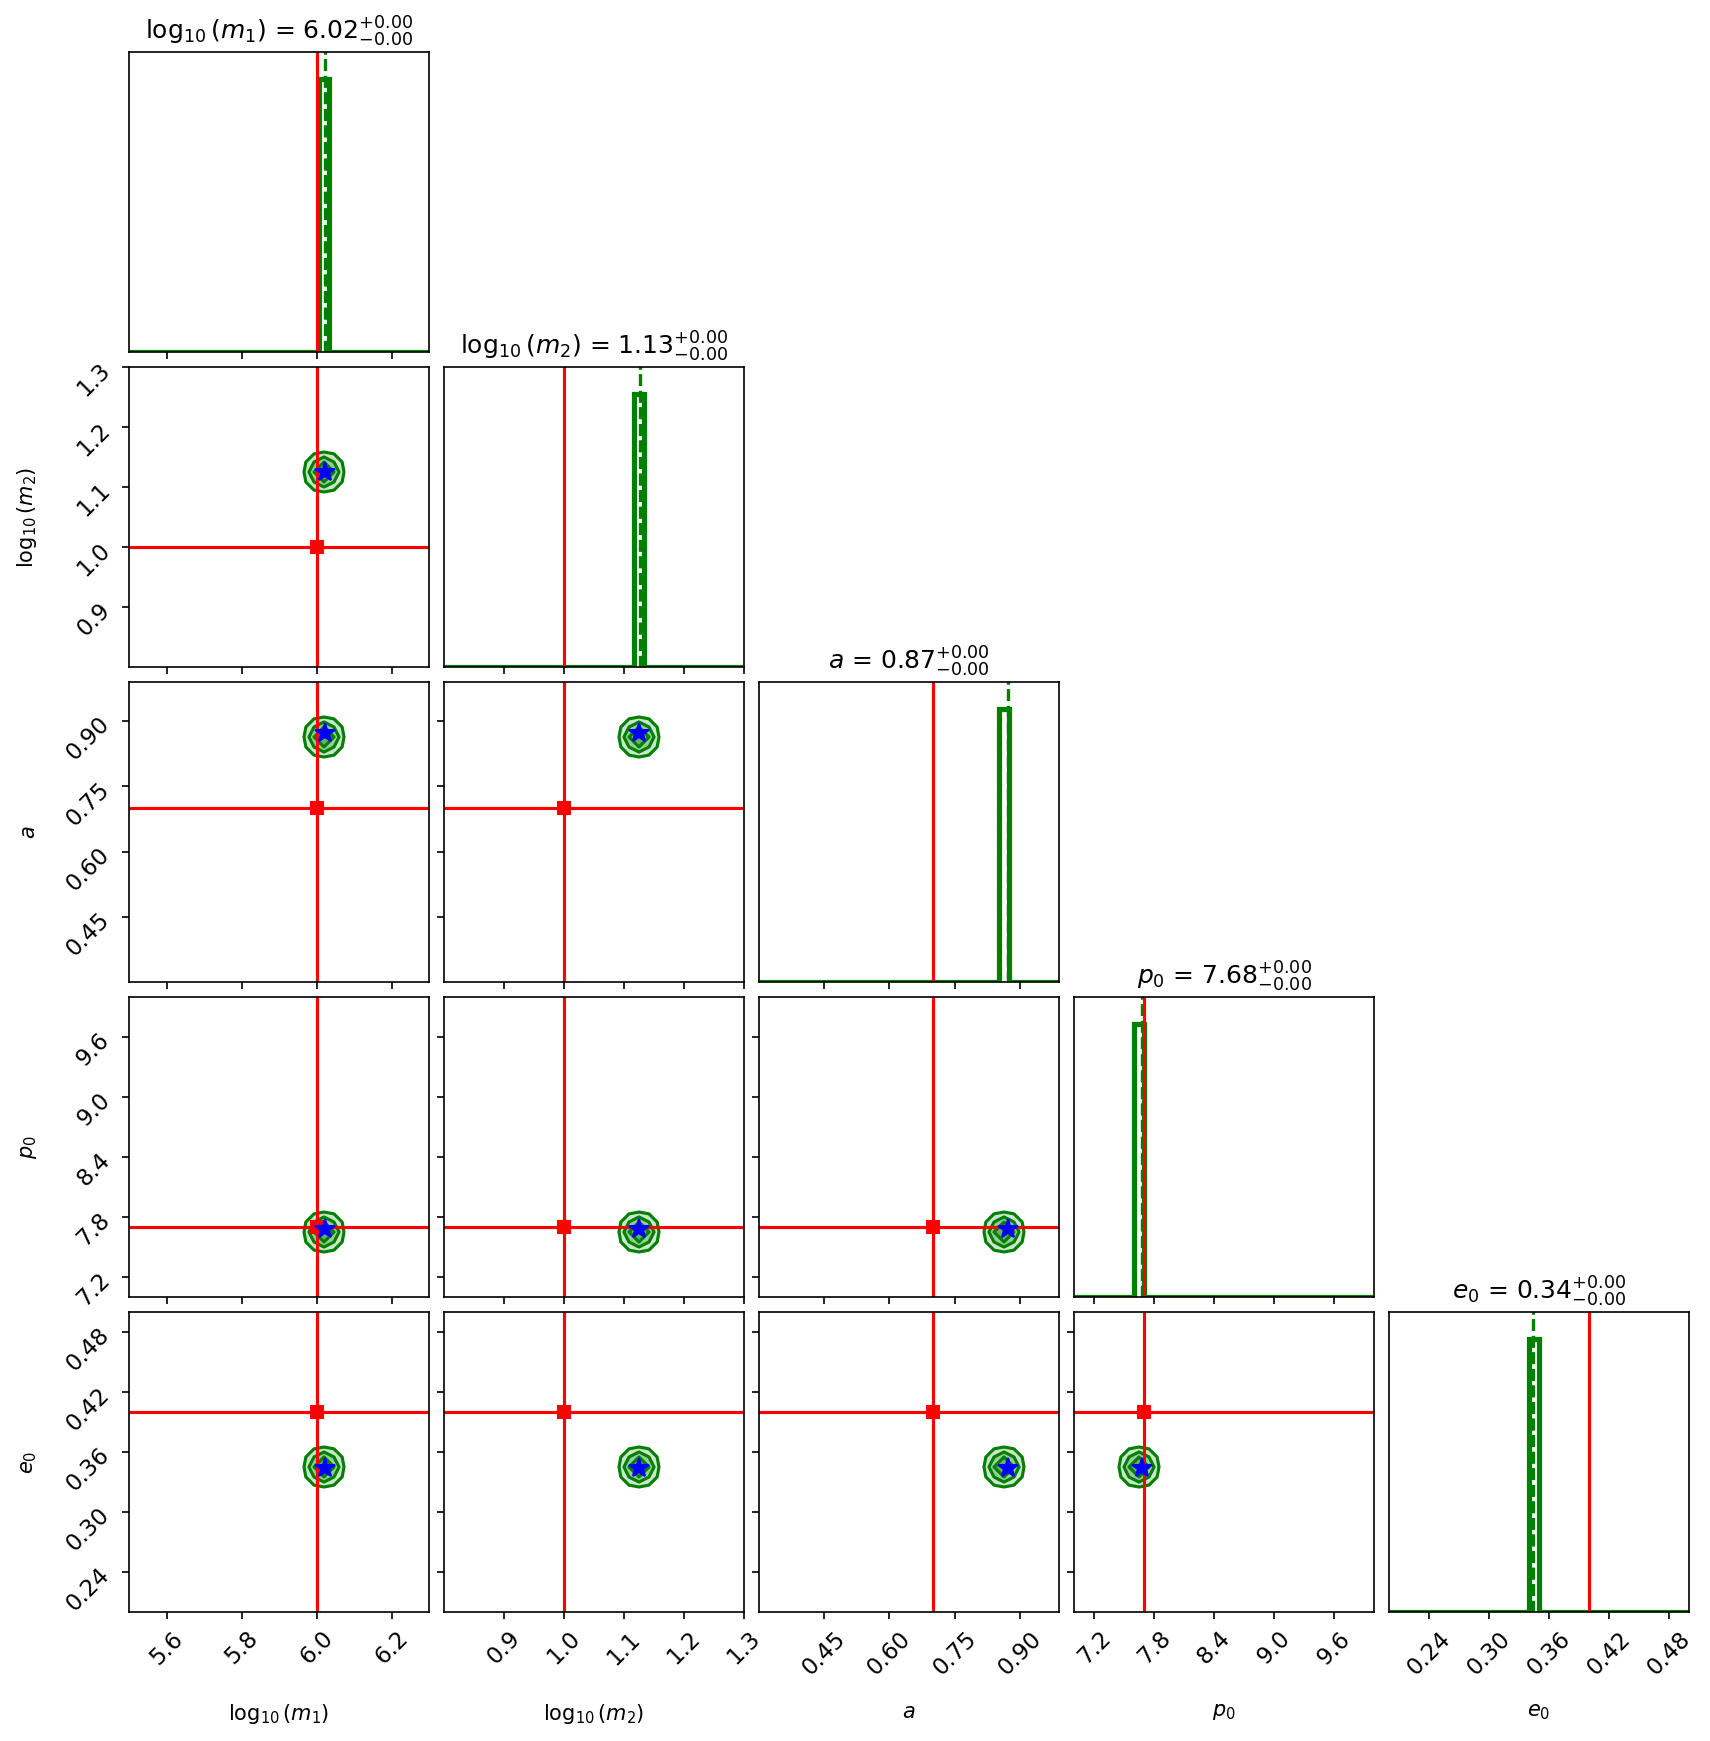

In [128]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [129]:
w_norm = weights / weights.sum()
ess = 1.0 / np.sum(w_norm**2)
print(f"ESS: {ess:.1f}  ({100*ess/len(weights):.2f}% of N={len(weights)})")

ESS: 1.0  (0.00% of N=100000)


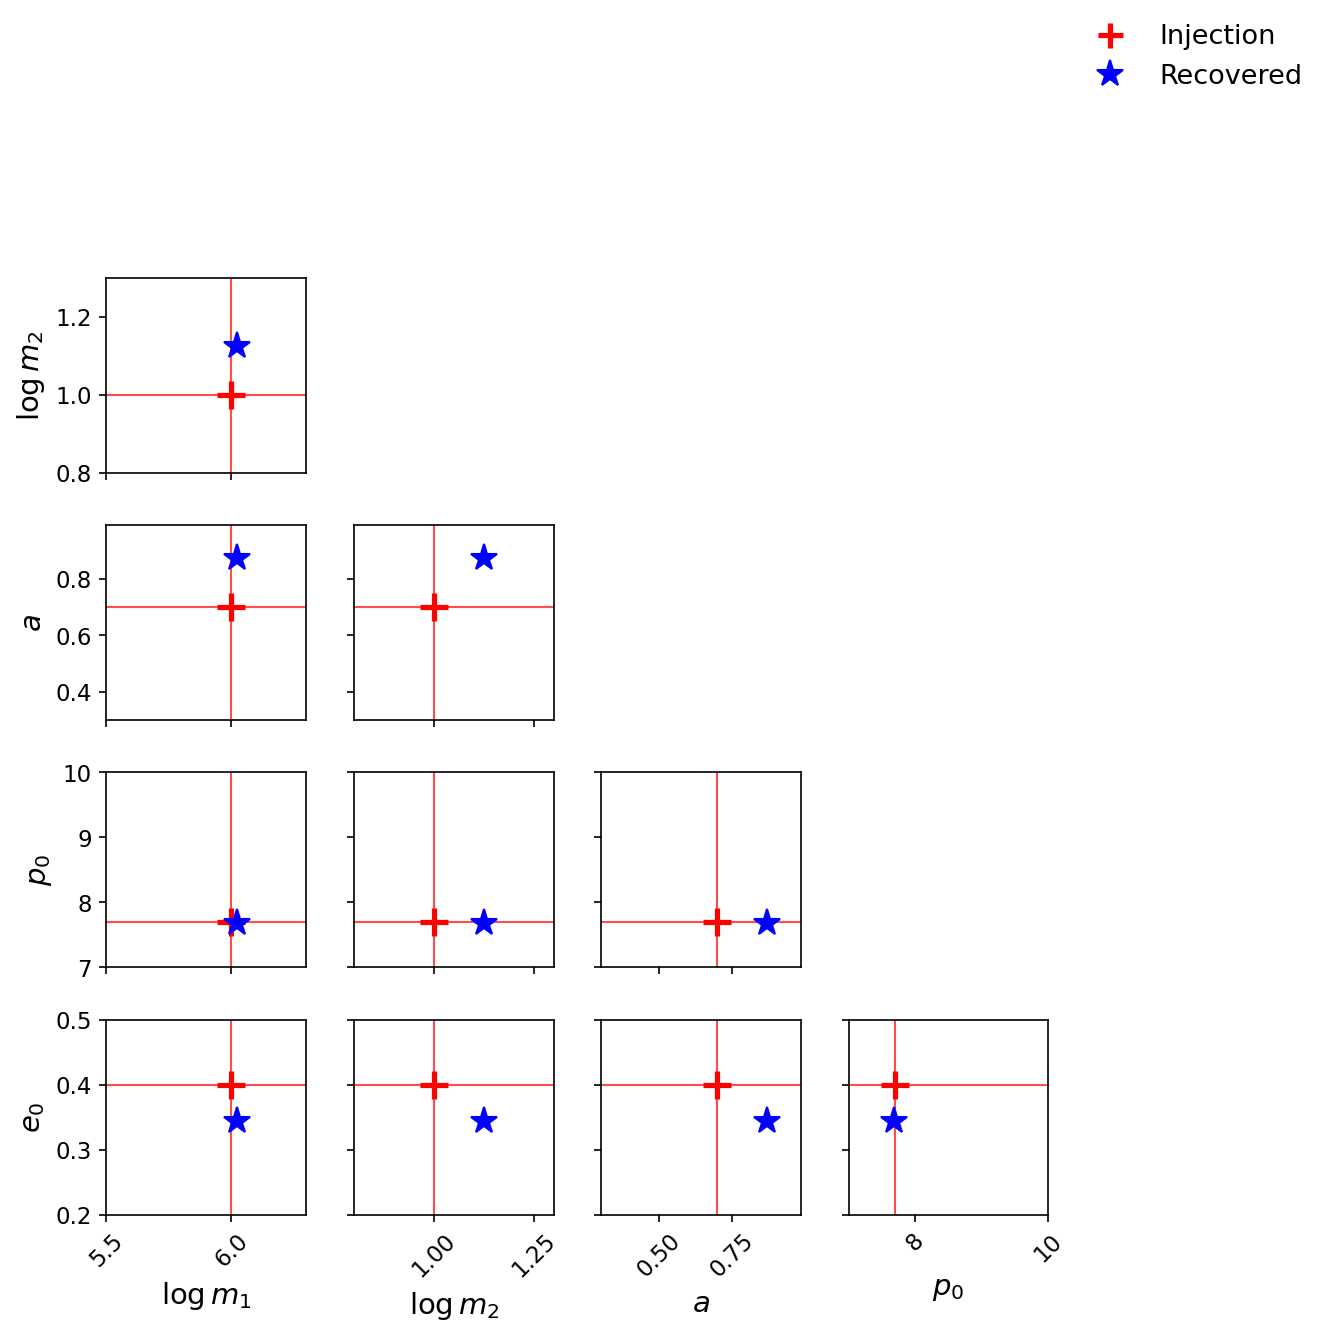

In [130]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

# tightened box: frac of the original width, centered on the MAP point,
# clipped back to the original box
frac = 0.7
old_lo = np.array([r[0] for r in param_ranges])
old_hi = np.array([r[1] for r in param_ranges])
old_width = old_hi - old_lo
box_lo = np.maximum(maxld_pt1 - frac / 2 * old_width, old_lo)
box_hi = np.minimum(maxld_pt1 + frac / 2 * old_width, old_hi)

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # # tightened (70%) box overlay
        # ax.add_patch(Rectangle(
        #     (box_lo[j], box_lo[i]),
        #     box_hi[j] - box_lo[j],
        #     box_hi[i] - box_lo[i],
        #     facecolor='none', edgecolor='green', lw=1.8, zorder=2,
        # ))

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
    # Line2D([0], [0], color='green', lw=1.8,                            label='Tightened box (70%)'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

In [131]:
# import pickle
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# from matplotlib.patches import Ellipse

# with open('/home/svu/e1498138/emri_search/work/cov_matrix_noise_1yr.pkl', 'rb') as f:
#     cov = pickle.load(f)

# def draw_cov_ellipse(ax, cx, cy, cov2d, n_sigma=1, **kwargs):
#     vals, vecs = np.linalg.eigh(cov2d)
#     order = vals.argsort()[::-1]
#     vals, vecs = vals[order], vecs[:, order]
#     angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
#     ell = Ellipse(xy=(cx, cy),
#                 width=2 * n_sigma * np.sqrt(vals[0]),
#                 height=2 * n_sigma * np.sqrt(vals[1]),
#                 angle=angle, **kwargs)
#     ax.add_patch(ell)

# _pt  = np.asarray(param_true).ravel()
# _map = np.asarray(maxld_pt1).ravel()
# sigs = np.sqrt(np.diag(cov))

# j, i = 0, 3   # x = log10(m1), y = p0
# cov2d = cov[np.ix_([j, i], [j, i])]

# xlo = min(_pt[j], _map[j]);  xhi = max(_pt[j], _map[j])
# ylo = min(_pt[i], _map[i]);  yhi = max(_pt[i], _map[i])
# xpad = (xhi - xlo) * 0.05 + 3 * sigs[j]
# ypad = (yhi - ylo) * 0.05 + 3 * sigs[i]

# fig, ax = plt.subplots(figsize=(6, 5))
# ax.set_xlim(xlo - xpad, xhi + xpad)
# ax.set_ylim(ylo - ypad, yhi + ypad)

# ax.axvline(_pt[j], color='red', lw=1.0, alpha=0.5, zorder=1)
# ax.axhline(_pt[i], color='red', lw=1.0, alpha=0.5, zorder=1)
# ax.plot(_pt[j], _pt[i], '+', color='red', ms=13, mew=2.5, zorder=3)
# ax.plot(_map[j], _map[i], '*', color='blue', ms=13, zorder=4)

# draw_cov_ellipse(ax, _pt[j], _pt[i], cov2d,
#                 n_sigma=2, facecolor='none', edgecolor='green', lw=5, zorder=2)

# ax.set_xlabel(r'$\log m_1$')
# ax.set_ylabel(r'$p_0$')
# sigs = np.sqrt(np.diag(cov))

# j, i = 0, 3   # x = log10(m1), y = p0
# cov2d = cov[np.ix_([j, i], [j, i])]
# a
# xlo = min(_pt[j], _map[j]);  xhi = max(_pt[j], _map[j])
# ylo = min(_pt[i], _map[i]);  yhi = max(_pt[i], _map[i])
# xpad = (xhi - xlo) * 0.05 + 3 * sigs[j]
# ypad = (yhi - ylo) * 0.05 + 3 * sigs[i]

# fig, ax = plt.subplots(figsize=(6, 5))
# ax.set_xlim(xlo - xpad, xhi + xpad)
# ax.set_ylim(ylo - ypad, yhi + ypad)

# ax.axvline(_pt[j], color='red', lw=1.0, alpha=0.5, zorder=1)
# ax.axhline(_pt[i], color='red', lw=1.0, alpha=0.5, zorder=1)
# ax.plot(_pt[j], _pt[i], '+', color='red', ms=13, mew=2.5, zorder=3)
# ax.plot(_map[j], _map[i], '*', color='blue', ms=13, zorder=4)

# draw_cov_ellipse(ax, _pt[j], _pt[i], cov2d,
#                 n_sigma=2, facecolor='none', edgecolor='green', lw=3, zorder=2)

# ax.set_xlabel(r'$\log  m_1$')
# ax.set_ylabel(r'$p_0$')

# legend_handles = [
#     Line2D([0], [0], color='red',   marker='+', ls='', ms=12, mew=2.5, alpha=0.5, label='Injection'),
#     Line2D([0], [0], color='blue',  marker='*', ls='', ms=13,           label='Recovered'),
#     Line2D([0], [0], color='green', ls='-',  lw=3,                      label='Fisher 2σ'),
# ]
# ax.legend(handles=legend_handles, frameon=False, fontsize=12)
# plt.tight_layout()
# plt.show()

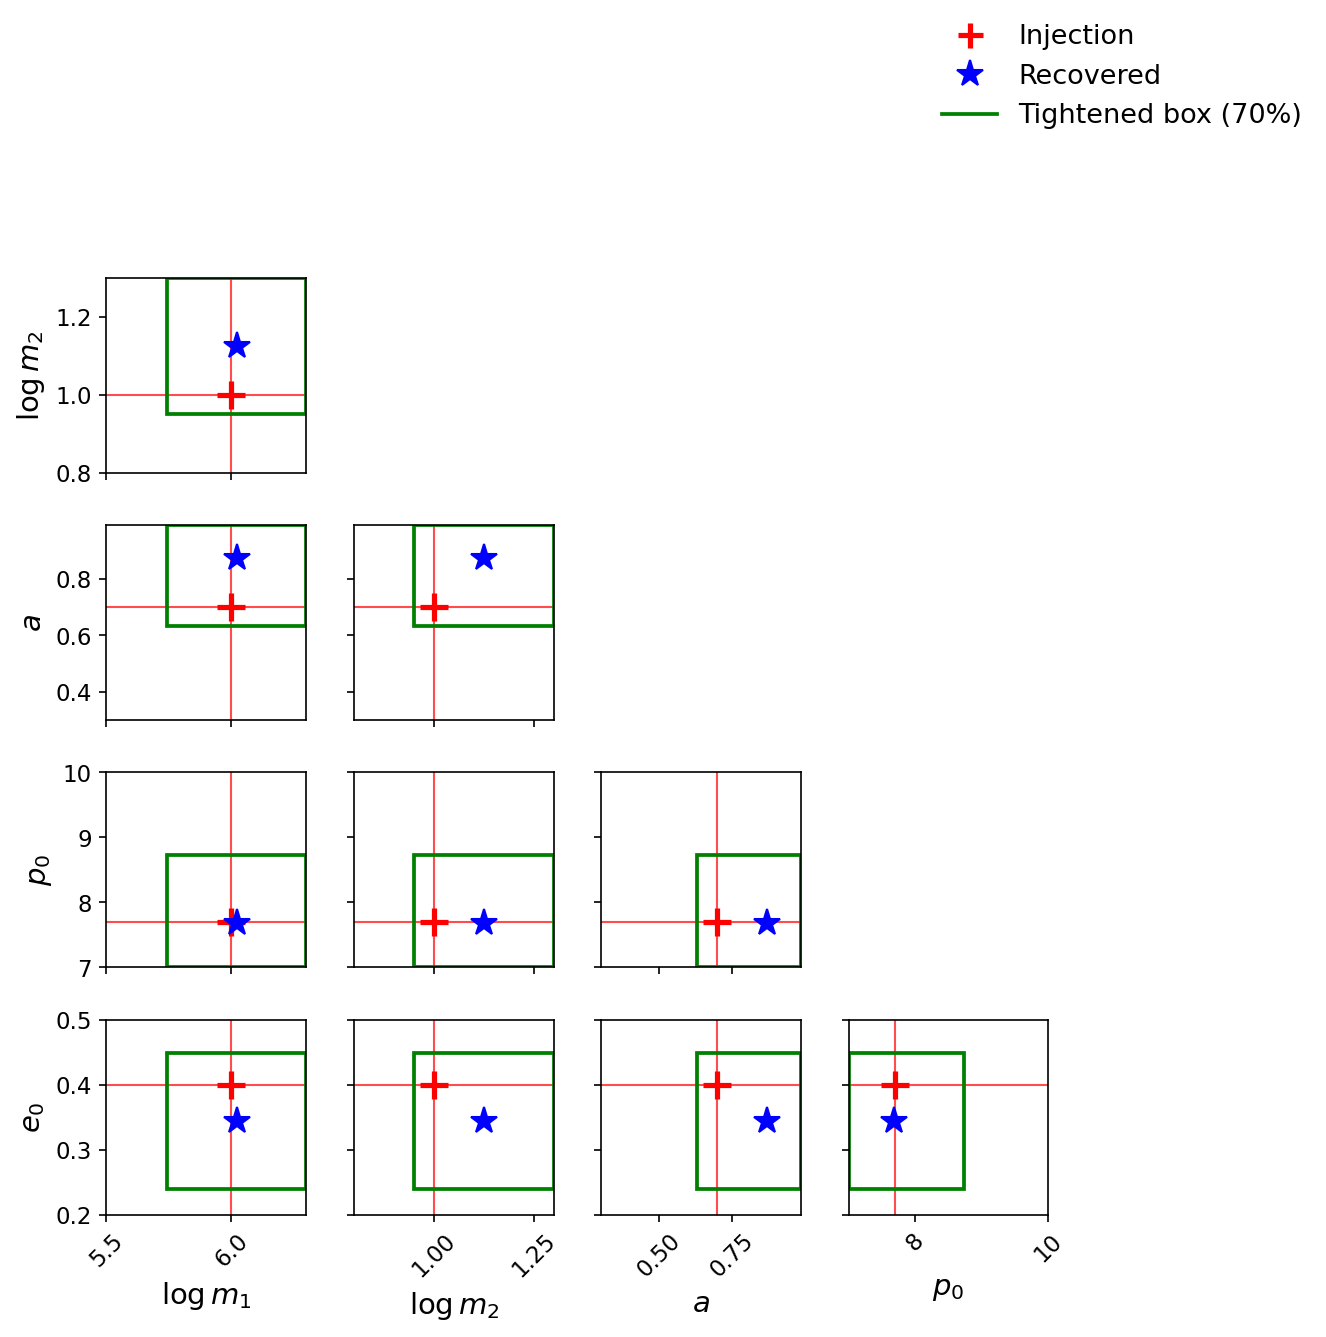

In [132]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

# tightened box: frac of the original width, centered on the MAP point,
# clipped back to the original box
frac = 0.7
old_lo = np.array([r[0] for r in param_ranges])
old_hi = np.array([r[1] for r in param_ranges])
old_width = old_hi - old_lo
box_lo = np.maximum(maxld_pt1 - frac / 2 * old_width, old_lo)
box_hi = np.minimum(maxld_pt1 + frac / 2 * old_width, old_hi)

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # tightened (70%) box overlay
        ax.add_patch(Rectangle(
            (box_lo[j], box_lo[i]),
            box_hi[j] - box_lo[j],
            box_hi[i] - box_lo[i],
            facecolor='none', edgecolor='green', lw=1.8, zorder=2,
        ))

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
    Line2D([0], [0], color='green', lw=1.8,                            label='Tightened box (70%)'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot

In [133]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1,-1)
proc1_maxld_pt

array([[6.02349103, 1.12567941, 0.8728248 , 7.68499057, 0.34427594]])

In [134]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0]
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [135]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [136]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [137]:
logden_theory_proc1

array([16.76062199, 15.42110651, 15.65222084, 15.81226396, 15.65305839,
       15.44423339, 15.23197254, 14.78925556, 15.31615372, 15.33306484,
       15.63114512, 14.711278  , 14.84463045, 15.08786217, 15.03766971,
       14.91530103, 15.27863282, 14.84902079, 15.2839398 , 14.8337221 ,
       14.74030763, 15.31630586, 14.46339402, 15.41503271, 14.55954022,
       14.94789408, 15.10801865, 15.11636291, 15.44872451, 15.45939102,
       15.31667113, 15.23481959, 15.25190953, 15.15744305, 15.44668461,
       15.58086827, 16.41701634, 15.76768223, 15.48088125, 15.61023233,
       16.14271463, 15.33039609, 15.41949499, 15.56496407, 15.80760571,
       16.00933743, 15.65649967, 15.6290325 , 16.14416504, 25.03443669])

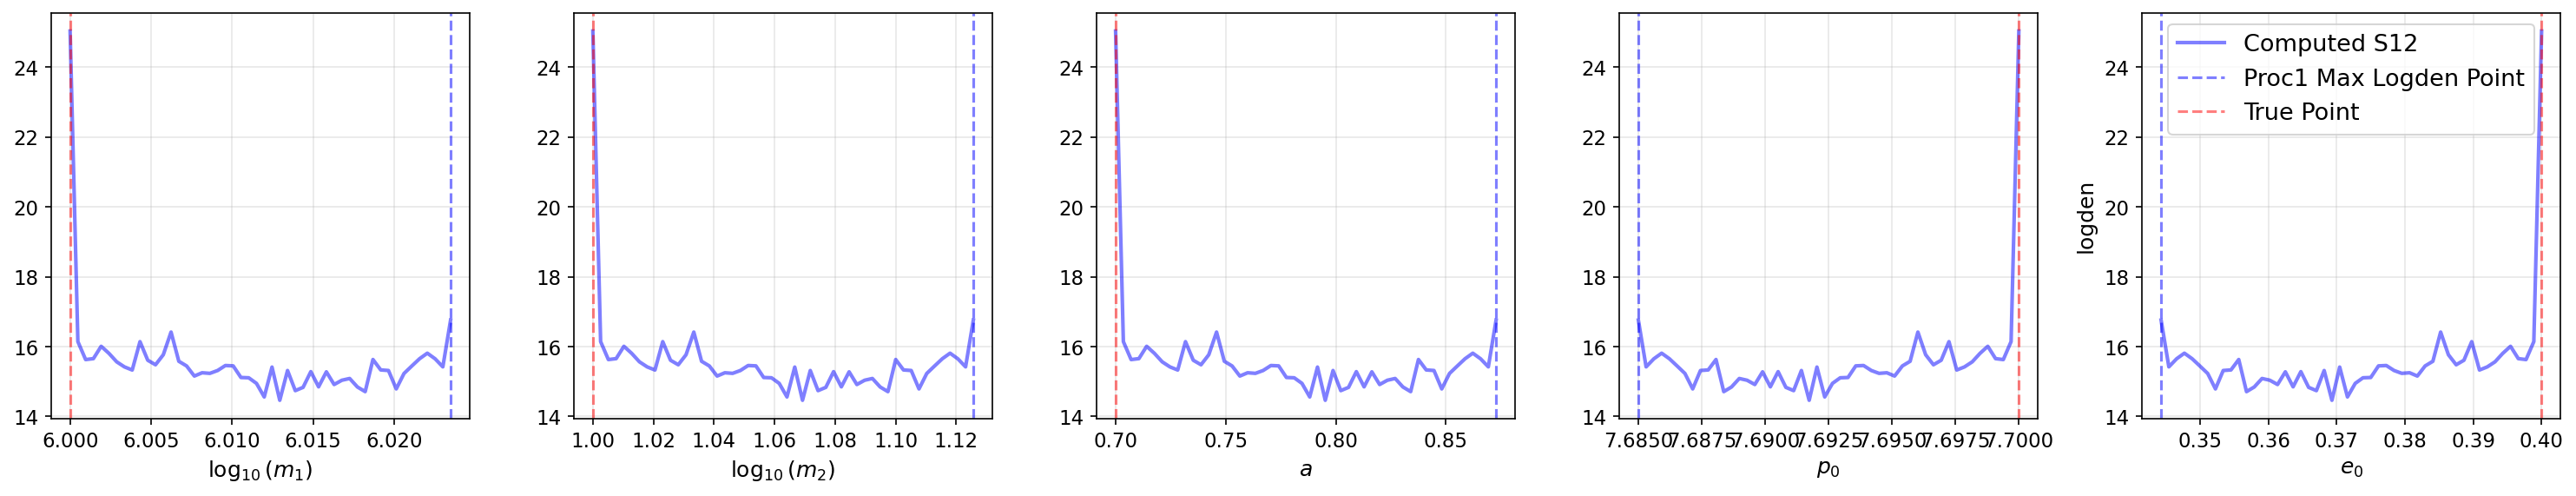

In [138]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed S12')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [139]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [140]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [141]:
logden_tm = log_density(line_points_logm1.T)


In [142]:
logden_tm

array([       -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
       14.34633674, 15.76873337, 15.53659105, 15.22316083, 16.76

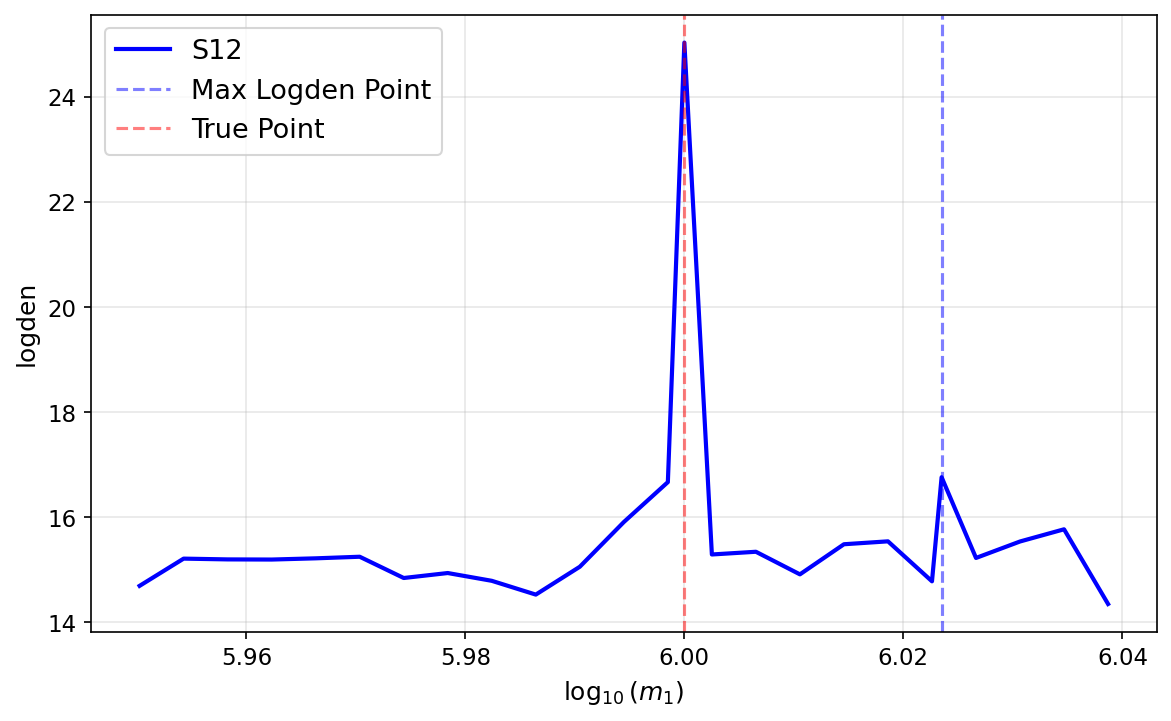

In [143]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='S12')
# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

In [144]:
# --- weighted sample covariance vs current PARIS covariance ---
samples, weights = sampler.get_samples_with_weights(flatten=True)
w_norm = weights / weights.sum()

center = maxld_pt1.reshape(-1)          # MAP point, used as box center
true_pt = np.asarray(param_true).ravel()

cov_sample = np.cov(samples.T, aweights=w_norm, ddof=0)
cov_paris  = sampler.now_covariances[-1]

print("sample cov diag sigma:", np.sqrt(np.diag(cov_sample)))
print("paris  cov diag sigma:", np.sqrt(np.diag(cov_paris)))

# --- n_sigma needed along the joint (Mahalanobis) direction ---
delta = true_pt - center
n_sigma_mahalanobis_sample = np.sqrt(delta @ np.linalg.inv(cov_sample) @ delta)
n_sigma_mahalanobis_paris  = np.sqrt(delta @ np.linalg.inv(cov_paris)  @ delta)

print(f"Mahalanobis n_sigma (sample cov): {n_sigma_mahalanobis_sample:.2f}")
print(f"Mahalanobis n_sigma (paris  cov): {n_sigma_mahalanobis_paris:.2f}")

# --- n_sigma needed per-dimension, if you go with an axis-aligned box ---
sigma_sample = np.sqrt(np.diag(cov_sample))
n_sigma_per_dim_sample = np.abs(delta) / sigma_sample

labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
for lbl, ns in zip(labels, n_sigma_per_dim_sample):
    print(f"{lbl}: needs {ns:.2f} sigma to contain truth")


sample cov diag sigma: [0.00023648 0.00022329 0.00037615 0.0025498  0.00018157]
paris  cov diag sigma: [0.00029577 0.00044668 0.00054523 0.00084999 0.00060532]
Mahalanobis n_sigma (sample cov): 1027.34
Mahalanobis n_sigma (paris  cov): 404.93
$\log_{10}(m_1)$: needs 99.34 sigma to contain truth
$\log_{10}(m_2)$: needs 562.86 sigma to contain truth
$a$: needs 459.46 sigma to contain truth
$p_0$: needs 5.89 sigma to contain truth
$e_0$: needs 306.90 sigma to contain truth


In [145]:
old_lo = np.array([r[0] for r in param_ranges])
old_hi = np.array([r[1] for r in param_ranges])
old_width = old_hi - old_lo

center = maxld_pt1.reshape(-1)          # MAP point
true_pt = np.asarray(param_true).ravel()

frac = 0.7   # e.g. keep 70% of the original box width, centered on MAP

new_lo = center - frac/2 * old_width
new_hi = center + frac/2 * old_width

# clip back to the original (physical) box so you never expand beyond it
new_lo = np.maximum(new_lo, old_lo)
new_hi = np.minimum(new_hi, old_hi)

new_param_ranges = list(zip(new_lo, new_hi))

contains_truth = np.all(new_lo <= true_pt) & np.all(true_pt <= new_hi)
print("contains truth:", contains_truth)
for lbl, lo, hi, t in zip(labels, new_lo, new_hi, true_pt):
    print(f"{lbl}: [{lo:.4f}, {hi:.4f}]  truth={t:.4f}  {'OK' if lo<=t<=hi else 'CUT'}")


contains truth: True
$\log_{10}(m_1)$: [5.7435, 6.3000]  truth=6.0000  OK
$\log_{10}(m_2)$: [0.9507, 1.3000]  truth=1.0000  OK
$a$: [0.6313, 0.9900]  truth=0.7000  OK
$p_0$: [7.0000, 8.7350]  truth=7.7000  OK
$e_0$: [0.2393, 0.4493]  truth=0.4000  OK


In [146]:
for frac in [0.3, 0.5, 0.7, 1.0]:
    new_lo = np.maximum(center - frac/2 * old_width, old_lo)
    new_hi = np.minimum(center + frac/2 * old_width, old_hi)
    ok = np.all(new_lo <= true_pt) & np.all(true_pt <= new_hi)
    print(f"frac={frac}: contains truth = {ok}")


frac=0.3: contains truth = False
frac=0.5: contains truth = False
frac=0.7: contains truth = True
frac=1.0: contains truth = True


In [147]:
i, j = 1, 2  # logm2, a
corr_sample = cov_sample[i, j] / np.sqrt(cov_sample[i, i] * cov_sample[j, j])
corr_paris  = cov_paris[i, j]  / np.sqrt(cov_paris[i, i]  * cov_paris[j, j])
print(f"corr(logm2, a): sample={corr_sample:.3f}, paris={corr_paris:.3f}")


corr(logm2, a): sample=0.774, paris=0.774
